# Data Integration and Feature Engineering

## 1. Introduction

This notebook integrates client and property datasets and transforms the combined information into a client-level feature dataset suitable for machine learning-based buyer segmentation.

The property dataset contains multiple records for individual clients. Therefore, property-level information is aggregated to create meaningful client-level behavioral and investment features.

The resulting dataset will be prepared through categorical encoding and feature scaling before applying clustering algorithms.

------------------

## 2. Import Libraries

The required libraries are imported for data loading, manipulation, feature engineering, and preprocessing.

In [1]:
import pandas as pd
import numpy as np

## 3. Load the Datasets

The cleaned client and property datasets are loaded into Pandas DataFrames.

The client dataset provides demographic and behavioral characteristics, while the property dataset provides transaction and property-level information.

In [2]:
clients_df = pd.read_csv('../data/Clients.csv')
property_df = pd.read_csv('../data/Properties.csv')

## Inspection of both datasets before integrating it

In [3]:
print("Client IDs:")
print(clients_df['client_id'].head(10))

print("\nProperty Client References:")
print(property_df['client_ref'].dropna().head(10))

Client IDs:
0    C0001
1    C0002
2    C0003
3    C0004
4    C0005
5    C0006
6    C0007
7    C0008
8    C0009
9    C0010
Name: client_id, dtype: str

Property Client References:
0    C0027
1    C0097
2    C0113
3    C0141
4    C0146
5    C0023
6    C0040
7    C0007
8    C0082
9    C0038
Name: client_ref, dtype: str


In [4]:
print("Unique clients:", clients_df['client_id'].nunique())
print("Unique property client references:", property_df['client_ref'].nunique())

Unique clients: 2000
Unique property client references: 2000


## Checking any unmatched property client reference

In [5]:
property_df['client_ref'].value_counts().describe()

count    2000.0000
mean        3.6525
std         0.8397
min         3.0000
25%         3.0000
50%         4.0000
75%         4.0000
max        13.0000
Name: count, dtype: float64

## 4. Integrate Client and Property Data

The client and property datasets are linked using the client identifier.

A client may be associated with multiple property records. Therefore, the merged dataset may contain multiple rows for the same client at this stage.

A left join is used with the client dataset as the primary table so that every client remains represented in the integrated dataset.

In [6]:
print("Property shape:", property_df.shape)
print("Client shape:", clients_df.shape)

Property shape: (10000, 9)
Client shape: (2000, 12)


In [7]:
merged_df = clients_df.merge(
    property_df,
    how = 'left',
    right_on = 'client_ref',
    left_on = 'client_id',
    
)

### 4.1 Validate Client References

The property client references are compared with the client IDs to identify property records that refer to clients not present in the client dataset.

Missing `client_ref` values are excluded from this comparison because they represent property records without a recorded client reference rather than invalid client IDs.

In [8]:
property_client_ids = set(property_df['client_ref'].dropna())
client_ids = set(clients_df['client_id'])

unmatched_ids = property_client_ids - client_ids

print("Unmatched property client references:", len(unmatched_ids))

Unmatched property client references: 0


In [9]:
merged_df.shape

(7305, 21)

In [10]:
merged_df.head(10)

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,...,referral_channel,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,90343,9,10-01-2024,Apartment,40,1090.32,"$351,419.29",Sold,C0001
1,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,4051,4,12-01-2024,Apartment,51,1608.84,"$496,266.41",Sold,C0001
2,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,150099,15,05-01-2025,Apartment,15,522.71,"$175,599.90",Sold,C0001
3,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,...,Website,30432,3,12-01-2025,Apartment,50,713.67,"$223,479.12",Sold,C0001
4,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,150044,15,01-01-2024,Apartment,6,938.57,"$299,245.20",Sold,C0002
5,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,1045,1,02-01-2024,Apartment,45,756.21,"$248,525.12",Sold,C0002
6,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,90285,9,12-01-2024,Apartment,36,1582.79,"$505,127.63",Sold,C0002
7,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,200450,20,05-01-2025,Apartment,51,1062.33,"$336,892.39",Sold,C0002
8,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,30377,3,12-01-2025,Apartment,46,1599.81,"$451,305.59",Sold,C0002
9,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,...,Agency,10104,1,07-01-2024,Apartment,13,719.47,"$216,874.97",Sold,C0003


## 5. Data Type Conversion and Cleaning

The integrated dataset contains some numerical and date-related fields stored as text.

These variables are converted into appropriate data types so that mathematical calculations and aggregation can be performed correctly.

In [11]:
merged_df[['floor_area_sqft', 'sale_price', 'transaction_date']].info()

<class 'pandas.DataFrame'>
RangeIndex: 7305 entries, 0 to 7304
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   floor_area_sqft   7305 non-null   float64
 1   sale_price        7305 non-null   str    
 2   transaction_date  7305 non-null   str    
dtypes: float64(1), str(2)
memory usage: 322.9 KB


In [12]:
merged_df[['floor_area_sqft', 'sale_price', 'transaction_date']].head()

,floor_area_sqft,sale_price,transaction_date
0,1090.32,"$351,419.29",10-01-2024
1,1608.84,"$496,266.41",12-01-2024
2,522.71,"$175,599.90",05-01-2025
3,713.67,"$223,479.12",12-01-2025
4,938.57,"$299,245.20",01-01-2024


### 5.1 Convert Sale Price to Numeric

The `sale_price` values contain currency symbols and comma separators.

These non-numeric characters are removed before converting the values to floating-point numbers.

In [13]:
merged_df['sale_price'] = (
    merged_df['sale_price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

### 5.2 Convert Transaction Date

The `transaction_date` column is converted from text into Pandas datetime format.

This allows the transaction dates to be used correctly for temporal analysis and future feature engineering.

In [14]:
merged_df['transaction_date'] = pd.to_datetime(
    merged_df['transaction_date'],
    format='mixed',
    dayfirst=False,
    errors='coerce'
)

In [15]:
merged_df[['floor_area_sqft', 'sale_price', 'transaction_date']].info()

<class 'pandas.DataFrame'>
RangeIndex: 7305 entries, 0 to 7304
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   floor_area_sqft   7305 non-null   float64       
 1   sale_price        7305 non-null   float64       
 2   transaction_date  7305 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(2)
memory usage: 171.3 KB


In [16]:
merged_df[['floor_area_sqft', 'sale_price', 'transaction_date']].head()

,floor_area_sqft,sale_price,transaction_date
0,1090.32,351419.29,2024-10-01
1,1608.84,496266.41,2024-12-01
2,522.71,175599.90,2025-05-01
3,713.67,223479.12,2025-12-01
4,938.57,299245.20,2024-01-01


In [17]:
merged_df[['sale_price', 'floor_area_sqft']].describe()

,sale_price,floor_area_sqft
count,7305.000000,7305.000000
mean,345072.000115,1141.147838
std,132053.768307,419.241645
min,97402.800000,410.710000
25%,232448.630000,782.150000
50%,330997.320000,1110.880000
75%,451237.670000,1501.640000
max,736652.270000,1957.160000


## 6. Client-Level Feature Engineering

The integrated data contains multiple property records per client.

To perform buyer segmentation, property-level information is aggregated so that each client is represented by a single row.

The following features are created to capture purchasing behavior and investment scale:

### 6.1 Property Count

`property_count` represents the number of property records associated with each client.

This feature can help distinguish clients with relatively few purchases from clients with repeated or larger-scale property activity.

In [18]:
property_count = (
    merged_df.groupby('client_id')['listing_id']
    .count()
    .reset_index(name='property_count')
)

property_count.head()

,client_id,property_count
0,C0001,4
1,C0002,5
2,C0003,5
3,C0004,6
4,C0005,13


### 6.2 Total Property Value

`total_property_value` represents the combined sale value of all linked properties for each client.

This feature is used as a proxy for the overall scale of a client's property activity.

Because the client dataset does not contain an income variable, this measure should not be interpreted as the client's income. Instead, it represents the value of their observed property transactions.

In [19]:
total_property_value = (
    merged_df.groupby('client_id')['sale_price']
    .sum()
    .reset_index(name='total_property_value')
)

total_property_value.head()

,client_id,total_property_value
0,C0001,1246764.72
1,C0002,1841095.93
2,C0003,1661457.59
3,C0004,1608263.51
4,C0005,3653385.38


### 6.3 Average Property Value

`average_property_value` represents the mean sale price of the properties associated with each client.

This feature helps identify differences in the typical property value associated with different buyers.

In [20]:
average_property_value = (
    merged_df.groupby('client_id')['sale_price']
    .mean()
    .reset_index(name='average_property_value')
)

average_property_value.head()

,client_id,average_property_value
0,C0001,311691.180000
1,C0002,368219.186000
2,C0003,332291.518000
3,C0004,268043.918333
4,C0005,281029.644615


### 6.4 Average Floor Area

`average_floor_area` represents the average size of properties associated with each client.

It provides an additional measure of the type and scale of properties purchased by different buyers.

In [21]:
average_floor_area = (
    merged_df.groupby('client_id')['floor_area_sqft']
    .mean()
    .reset_index(name='average_floor_area')
)

average_floor_area.head()

,client_id,average_floor_area
0,C0001,983.885000
1,C0002,1187.942000
2,C0003,1058.110000
3,C0004,937.103333
4,C0005,927.296154


## 7. Combine Property-Level Features

The property-level features created above are combined into a single client-level feature dataset using `client_id` as the common key.

This allows the different measures of property activity to be analyzed together for each client.

In [22]:
client_features = property_count.merge(
    total_property_value,
    on='client_id',
    how='left'
)

client_features.head()

,client_id,property_count,total_property_value
0,C0001,4,1246764.72
1,C0002,5,1841095.93
2,C0003,5,1661457.59
3,C0004,6,1608263.51
4,C0005,13,3653385.38


### 7.1 Add Average Property Value

The `average_property_value` feature is merged with the existing client-level property features using `client_id`.

This adds information about the typical value of properties associated with each client.

In [23]:
client_features = client_features.merge(
    average_property_value,
    on='client_id',
    how='left'
)

### 7.2 Add Average Floor Area

The `average_floor_area` feature is merged into the client-level feature dataset using `client_id`.

This completes the set of aggregated property features, providing information about the number, value, and average size of properties associated with each client.

In [24]:
client_features = client_features.merge(
    average_floor_area,
    on='client_id',
    how='left'
)

In [25]:
client_features.head()

,client_id,property_count,total_property_value,average_property_value,average_floor_area
0,C0001,4,1246764.72,311691.180000,983.885000
1,C0002,5,1841095.93,368219.186000,1187.942000
2,C0003,5,1661457.59,332291.518000,1058.110000
3,C0004,6,1608263.51,268043.918333,937.103333
4,C0005,13,3653385.38,281029.644615,927.296154


In [26]:
client_features.shape

(2000, 5)

In [27]:
client_features.isnull().sum()

client_id                 0
property_count            0
total_property_value      0
average_property_value    0
average_floor_area        0
dtype: int64

## 8. Create Client Age Feature

The `date_of_birth` column is converted from a text format into a datetime format to enable age calculation.

A reference date is then used to calculate the age of each client. Age provides a more useful demographic feature for buyer segmentation than the original date of birth.

In [28]:
clients_df['date_of_birth'] = pd.to_datetime(
    clients_df['date_of_birth'],
    format='mixed',
    dayfirst=False,
    errors='coerce'
)

reference_date = pd.Timestamp('2026-01-01')

clients_df['age'] = (
    (reference_date - clients_df['date_of_birth']).dt.days // 365
)

### 8.1 Validate Age

The derived `age` feature is examined to verify that the calculated ages are reasonable and that the conversion did not produce invalid or missing values.

In [29]:
clients_df[['age']].head()

,age
0,57
1,63
2,66
3,66
4,49


## 9. Select Relevant Client Features

Relevant demographic and behavioral variables are selected from the client dataset for buyer segmentation.

Personal identifiers such as `first_name` and `last_name` are excluded because they do not provide meaningful information about buyer characteristics. The original `date_of_birth` is also excluded because the derived `age` feature provides a more suitable numerical representation for clustering.

In [30]:
client_info = clients_df[
    [
        'client_id',
        'client_type',
        'gender',
        'country',
        'region',
        'acquisition_purpose',
        'satisfaction_score',
        'loan_applied',
        'referral_channel',
        'age'
    ]
]

client_info.head()

,client_id,client_type,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age
0,C0001,Individual,F,USA,California,Home,4,Yes,Website,57
1,C0002,Individual,M,USA,California,Home,1,No,Website,63
2,C0003,Individual,M,USA,California,Home,4,Yes,Agency,66
3,C0004,Individual,M,USA,California,Home,5,No,Website,66
4,C0005,Company,M,USA,California,Investment,5,No,Website,49


## 9.1 Combine Client and Property Features

The selected client characteristics are combined with the aggregated property features to create a complete client-level dataset.

The features are merged using `client_id` as the common identifier. A left join is used so that all clients in the client dataset remain included in the final dataset.

The resulting dataset combines demographic and behavioral characteristics with property-related measures such as property count, total property value, average property value, and average floor area.

In [31]:
client_features = client_info.merge(
    property_count,
    on='client_id',
    how='left'
)

client_features = client_features.merge(
    total_property_value,
    on='client_id',
    how='left'
)

client_features = client_features.merge(
    average_property_value,
    on='client_id',
    how='left'
)

client_features = client_features.merge(
    average_floor_area,
    on='client_id',
    how='left'
)

### 9.2 Validate the Combined Dataset

The dimensions and missing values of the resulting client-level feature dataset are checked to ensure that the merging process was completed correctly.

The expected result is one row per client with the relevant client and property features.

In [32]:
client_features.shape

(2000, 14)

In [33]:
client_features.isnull().sum()

client_id                 0
client_type               0
gender                    0
country                   0
region                    0
acquisition_purpose       0
satisfaction_score        0
loan_applied              0
referral_channel          0
age                       0
property_count            0
total_property_value      0
average_property_value    0
average_floor_area        0
dtype: int64

In [34]:
client_features.head()

,client_id,client_type,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,property_count,total_property_value,average_property_value,average_floor_area
0,C0001,Individual,F,USA,California,Home,4,Yes,Website,57,4,1246764.72,311691.180000,983.885000
1,C0002,Individual,M,USA,California,Home,1,No,Website,63,5,1841095.93,368219.186000,1187.942000
2,C0003,Individual,M,USA,California,Home,4,Yes,Agency,66,5,1661457.59,332291.518000,1058.110000
3,C0004,Individual,M,USA,California,Home,5,No,Website,66,6,1608263.51,268043.918333,937.103333
4,C0005,Company,M,USA,California,Investment,5,No,Website,49,13,3653385.38,281029.644615,927.296154


In [35]:
client_features.columns

Index(['client_id', 'client_type', 'gender', 'country', 'region',
       'acquisition_purpose', 'satisfaction_score', 'loan_applied',
       'referral_channel', 'age', 'property_count', 'total_property_value',
       'average_property_value', 'average_floor_area'],
      dtype='str')

## 10. Inspect the Final Feature Dataset

Descriptive statistics are examined for the numerical features in the final client-level dataset.

This helps verify the ranges and distributions of the demographic and property-related variables before applying machine learning preprocessing.

In [36]:
client_features.describe()

,satisfaction_score,age,property_count,total_property_value,average_property_value,average_floor_area
count,2000.000000,2000.00000,2000.0000,2.000000e+03,2000.000000,2000.000000
mean,3.029000,55.14700,3.6525,1.260375e+06,347089.955869,1147.479668
std,1.413562,17.35572,0.8397,3.478307e+05,69721.821814,219.922587
min,1.000000,25.00000,3.0000,4.636120e+05,154537.316667,564.010000
25%,2.000000,40.00000,3.0000,1.025238e+06,295807.677708,984.952500
50%,3.000000,56.00000,4.0000,1.220893e+06,341523.383333,1129.176667
75%,4.000000,70.00000,4.0000,1.441974e+06,390843.316875,1296.562500
max,5.000000,94.00000,13.0000,3.653385e+06,563423.500000,1800.450000


### 10.1 Feature Data Types

The data types of the final features are examined to distinguish numerical variables from categorical variables.

This distinction is necessary because numerical and categorical variables require different preprocessing techniques before clustering.

In [37]:
client_features.dtypes

client_id                     str
client_type                   str
gender                        str
country                       str
region                        str
acquisition_purpose           str
satisfaction_score          int64
loan_applied                  str
referral_channel              str
age                         int64
property_count              int64
total_property_value      float64
average_property_value    float64
average_floor_area        float64
dtype: object

### Dropping the 'client_id' since it will not play a important role in ml

In [38]:
ml_features = client_features.drop(columns=['client_id'])

ml_features.head()

,client_type,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,property_count,total_property_value,average_property_value,average_floor_area
0,Individual,F,USA,California,Home,4,Yes,Website,57,4,1246764.72,311691.180000,983.885000
1,Individual,M,USA,California,Home,1,No,Website,63,5,1841095.93,368219.186000,1187.942000
2,Individual,M,USA,California,Home,4,Yes,Agency,66,5,1661457.59,332291.518000,1058.110000
3,Individual,M,USA,California,Home,5,No,Website,66,6,1608263.51,268043.918333,937.103333
4,Company,M,USA,California,Investment,5,No,Website,49,13,3653385.38,281029.644615,927.296154


### 11.1 Identify Categorical Features

The categorical variables are examined to determine the number of unique categories in each feature.

This helps assess the dimensionality that will result from one-hot encoding before the features are passed to the clustering algorithm.

In [39]:
for col in [
    'client_type',
    'gender',
    'country',
    'region',
    'acquisition_purpose',
    'loan_applied',
    'referral_channel'
]:
    print(f"\n{col}:")
    print(ml_features[col].nunique(), "unique values")


client_type:
2 unique values

gender:
2 unique values

country:
10 unique values

region:
57 unique values

acquisition_purpose:
2 unique values

loan_applied:
2 unique values

referral_channel:
3 unique values


## 12. Categorical Feature Encoding

K-Means clustering requires numerical input, while several buyer characteristics in the dataset are categorical.

One-hot encoding is used to convert categorical variables into binary numerical features. Each category is represented by a separate column containing 0 or 1.

This allows categorical characteristics such as client type, country, region, acquisition purpose, loan behavior, and referral channel to be incorporated into the clustering process.

In [40]:
categorical_columns = [
    'client_type',
    'gender',
    'country',
    'region',
    'acquisition_purpose',
    'loan_applied',
    'referral_channel'
]

encoded_features = pd.get_dummies(
    ml_features,
    columns=categorical_columns,
    drop_first=False,
    dtype=int
)

encoded_features.head()

,satisfaction_score,age,property_count,total_property_value,average_property_value,average_floor_area,client_type_Company,client_type_Individual,gender_F,gender_M,...,region_Western Australia,region_Wyoming,region_Zealand,acquisition_purpose_Home,acquisition_purpose_Investment,loan_applied_No,loan_applied_Yes,referral_channel_Agency,referral_channel_Client,referral_channel_Website
0,4,57,4,1246764.72,311691.180000,983.885000,0,1,1,0,...,0,0,0,1,0,0,1,0,0,1
1,1,63,5,1841095.93,368219.186000,1187.942000,0,1,0,1,...,0,0,0,1,0,1,0,0,0,1
2,4,66,5,1661457.59,332291.518000,1058.110000,0,1,0,1,...,0,0,0,1,0,0,1,1,0,0
3,5,66,6,1608263.51,268043.918333,937.103333,0,1,0,1,...,0,0,0,1,0,1,0,0,0,1
4,5,49,13,3653385.38,281029.644615,927.296154,1,0,0,1,...,0,0,0,0,1,1,0,0,0,1


In [41]:
encoded_features.shape

(2000, 84)

### 12.1 Encoding Result

After one-hot encoding, the dataset contains 2,000 clients and 84 numerical features.

The increase in the number of columns is expected because each category in the categorical variables is represented by a separate binary feature.

## 13. Feature Scaling

The features in the dataset have different numerical ranges. For example, `satisfaction_score` ranges from 1 to 5, `age` ranges from 25 to 94, while `total_property_value` contains values in the millions.

Since K-Means clustering uses distance to measure similarity between clients, features with larger numerical values could have a greater influence on the clustering results.

To prevent this, StandardScaler is used to standardize the features so that they are placed on a comparable scale.

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_features = scaler.fit_transform(encoded_features)

### 13.1 Standardization Using StandardScaler

`StandardScaler` transforms the features so that each feature has a mean close to 0 and a standard deviation close to 1.

The `fit_transform()` method first learns the statistical properties of the features and then applies the standardization.

The original `encoded_features` DataFrame is not modified. The standardized values are stored separately in `scaled_features`.

In [43]:
scaled_features.shape

(2000, 84)

### 13.2 Final Feature Matrix

After categorical encoding and feature scaling, the dataset contains 2,000 clients represented by 84 standardized numerical features.

This feature matrix is now ready for the clustering stage. The next step is to determine the appropriate number of buyer segments before applying the K-Means algorithm.

## 14. K-Means Clustering

K-Means clustering is an unsupervised machine learning algorithm used to group clients based on similarities across their demographic, behavioral, and property-related characteristics.

The algorithm divides the clients into `K` clusters, where each client is assigned to the cluster with the nearest centroid.

Since the appropriate number of buyer segments is not known in advance, multiple values of `K` will be evaluated rather than assuming a fixed number of clusters.

### 14.1 Initialize K-Means

The K-Means algorithm from Scikit-learn is imported to perform buyer segmentation.

Different values of `K` will be tested to identify a suitable number of clusters for the dataset.

In [44]:
from sklearn.cluster import KMeans

### 14.2 Evaluate Different Cluster Sizes

Multiple values of `K` are tested to determine how the clustering structure changes as the number of clusters increases.

The within-cluster sum of squares (inertia) will be recorded for each value of `K`. This measure will later be used with the Elbow Method to identify a suitable number of clusters.

In [45]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

### 14.3 Elbow Method

The Elbow Method is used to identify a suitable number of clusters.

The inertia values obtained for different values of `K` are plotted. As the number of clusters increases, inertia decreases because clients are divided into smaller groups.

The point where the reduction in inertia begins to slow down forms an approximate "elbow" in the curve. This point provides a candidate value for the number of clusters.

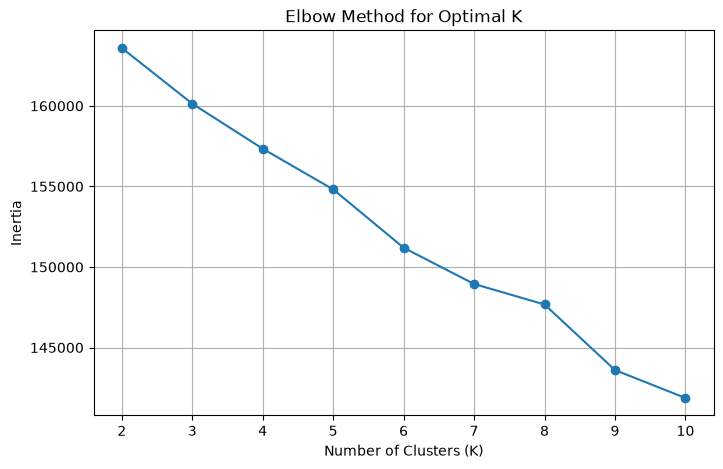

In [46]:
import matplotlib.pyplot as plt

k_values = range(2, 11)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_values)
plt.grid(True)
plt.show()

### 14.4 Elbow Method Interpretation

The inertia decreases as the number of clusters increases, which is expected because increasing the number of clusters generally allows clients to be grouped more closely around their respective centroids.

However, the elbow curve does not show a single sharp and unambiguous elbow point. Therefore, the Elbow Method alone is not sufficient to determine the final number of clusters.

The Silhouette Score will be evaluated alongside the Elbow Method to assess cluster cohesion and separation before selecting the final value of K.

## 15. Silhouette Score Analysis

The Silhouette Score is used to evaluate the quality of clustering for different values of K.

It measures how similar each client is to the other clients within its own cluster compared with clients in other clusters.

A higher Silhouette Score generally indicates that clusters are more cohesive internally and better separated from one another.

Silhouette Scores for K values from 2 to 10 will be calculated and compared with the Elbow Method results.

In [47]:
from sklearn.metrics import silhouette_score

In [48]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(scaled_features)
    
    score = silhouette_score(
        scaled_features,
        cluster_labels
    )
    
    silhouette_scores.append(score)

### 15.1 Visualize Silhouette Scores

The calculated Silhouette Scores are plotted for different values of `K`.

The plot helps compare the quality of the clustering structure across different numbers of clusters. A higher Silhouette Score indicates better-defined and more clearly separated clusters.

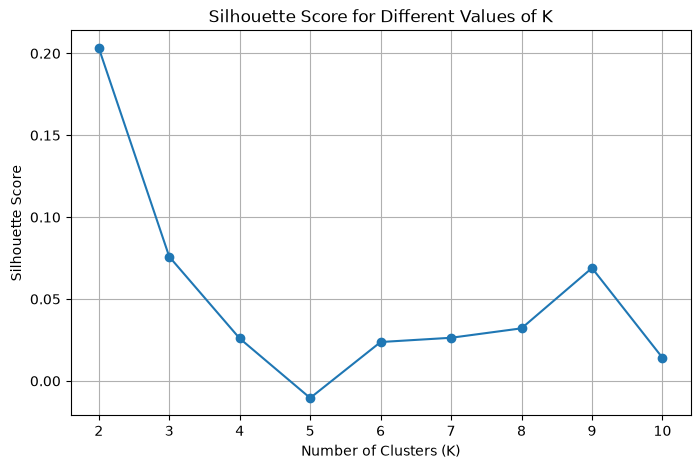

In [49]:
k_values = range(2, 11)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Values of K')
plt.xticks(k_values)
plt.grid(True)
plt.show()

### 15.2 Silhouette Score Interpretation

The Silhouette Score is highest for `K = 2`, with a score of approximately 0.20. The remaining tested values produce substantially lower scores.

However, the overall scores are relatively low, indicating that the clusters are not strongly separated in the current feature space.

Therefore, the Silhouette Score is used as an important diagnostic measure rather than as the sole basis for selecting the final clustering solution. The Elbow Method, cluster sizes, and interpretability of the resulting buyer segments will also be considered before determining the final value of `K`.

## 16. Compare Clustering Evaluation Metrics

The Elbow Method and Silhouette Score provide complementary information about clustering quality.

To make the comparison easier, the inertia and Silhouette Score for each tested value of `K` are combined into a single table.

This allows the candidate cluster solutions to be evaluated using multiple criteria rather than relying on a single metric.

In [50]:
cluster_evaluation = pd.DataFrame({
    'K': list(range(2, 11)),
    'Inertia': inertia,
    'Silhouette_Score': silhouette_scores
})

cluster_evaluation

,K,Inertia,Silhouette_Score
0,2,163591.710927,0.203273
1,3,160136.115827,0.075841
2,4,157340.512406,0.025923
3,5,154816.893080,-0.010432
4,6,151195.733871,0.023744
5,7,148944.972050,0.026342
6,8,147672.554867,0.032105
7,9,143603.290704,0.068933
8,10,141868.543057,0.014162


### 15.3 Comparison of K-Means Evaluation Metrics

The evaluation results show that inertia decreases as the number of clusters increases, as expected.

The highest Silhouette Score among the tested K values is obtained at `K = 2`, with a score of approximately 0.203. However, the overall Silhouette Scores are relatively low, indicating that the buyer groups are not strongly separated in the current feature space.

The Elbow Method also does not provide a single, clearly defined elbow point. Therefore, the final clustering solution will not be selected using the Elbow Method or Silhouette Score alone.

Hierarchical Clustering will also be evaluated to compare the clustering structure obtained using a different methodology.

## 16. Hierarchical Clustering

Hierarchical clustering is used as a second clustering approach to identify groups of similar buyers.

Agglomerative Hierarchical Clustering starts by treating each client as an individual cluster and progressively merges the most similar clusters.

Unlike K-Means, this approach builds a hierarchy of clusters and can provide a different perspective on the underlying structure of the buyer data.

The results will be evaluated for multiple cluster counts and compared with the K-Means results.

### 16.1 Agglomerative Clustering

Agglomerative Clustering from Scikit-learn is used to create hierarchical buyer segments.

Different values of the number of clusters will be tested so that the resulting clustering quality can be compared using the Silhouette Score.

In [51]:
from sklearn.cluster import AgglomerativeClustering

### 16.2 Evaluate Different Cluster Sizes

Multiple values of the number of clusters are evaluated using Agglomerative Hierarchical Clustering.

For each value of `K`, the Silhouette Score is calculated to measure how well the resulting clusters are separated.

Using the same range of cluster counts as the K-Means analysis allows the two clustering approaches to be compared consistently.

In [52]:
hierarchical_silhouette_scores = []

for k in range(2, 11):
    hierarchical = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )
    
    cluster_labels = hierarchical.fit_predict(scaled_features)
    
    score = silhouette_score(
        scaled_features,
        cluster_labels
    )
    
    hierarchical_silhouette_scores.append(score)
    

### 16.3 Silhouette Score Visualization

The Silhouette Scores obtained from Agglomerative Hierarchical Clustering are plotted for different values of `K`.

The results are used to identify cluster counts that produce better-defined and better-separated groups.

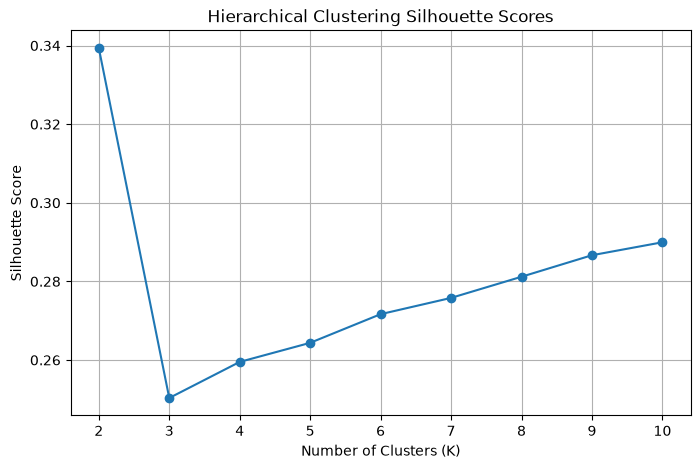

In [53]:
k_values = range(2, 11)

plt.figure(figsize=(8, 5))
plt.plot(
    k_values,
    hierarchical_silhouette_scores,
    marker='o'
)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Hierarchical Clustering Silhouette Scores')
plt.xticks(k_values)
plt.grid(True)
plt.show()

### 16.4 Hierarchical Clustering Evaluation

The Silhouette Scores for the different hierarchical clustering solutions are summarized in a table.

This provides a numerical comparison of clustering quality across the tested values of `K`.

In [54]:
hierarchical_evaluation = pd.DataFrame({
    'K': list(range(2, 11)),
    'Silhouette_Score': hierarchical_silhouette_scores
})

hierarchical_evaluation

,K,Silhouette_Score
0,2,0.339380
1,3,0.250336
2,4,0.259515
3,5,0.264372
4,6,0.271662
5,7,0.275801
6,8,0.281182
7,9,0.286658
8,10,0.289954


## 17. Compare K-Means and Hierarchical Clustering

The two clustering approaches are compared using their Silhouette Scores.

K-Means was evaluated using both inertia and Silhouette Score, while Hierarchical Clustering was evaluated using the Silhouette Score.

Comparing the two approaches helps determine which method produces better-separated and more meaningful buyer segments for this dataset.

In [55]:
comparison = pd.DataFrame({
    'K': list(range(2, 11)),
    'KMeans_Silhouette': silhouette_scores,
    'Hierarchical_Silhouette': hierarchical_silhouette_scores
})

comparison

,K,KMeans_Silhouette,Hierarchical_Silhouette
0,2,0.203273,0.339380
1,3,0.075841,0.250336
2,4,0.025923,0.259515
3,5,-0.010432,0.264372
4,6,0.023744,0.271662
5,7,0.026342,0.275801
6,8,0.032105,0.281182
7,9,0.068933,0.286658
8,10,0.014162,0.289954


### 17.1 Clustering Comparison Results

The comparison shows that `K = 2` produces the highest Silhouette Score for both clustering approaches.

For K-Means, the highest Silhouette Score is approximately 0.203, while Hierarchical Clustering achieves a higher score of approximately 0.339 at `K = 2`.

Although the Silhouette Score provides evidence about cluster separation, it is not used as the only criterion for selecting the final segmentation. The resulting cluster sizes and buyer characteristics will also be examined to determine whether the clusters provide meaningful and interpretable buyer segments.

## 18. Candidate Cluster Analysis

Based on the clustering evaluation, `K = 2` is examined in greater detail for both K-Means and Hierarchical Clustering.

Cluster labels are generated for the two methods so that their cluster sizes and buyer characteristics can be compared.

In [56]:
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_2.fit_predict(scaled_features)

In [57]:
hierarchical_2 = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

hierarchical_labels = hierarchical_2.fit_predict(scaled_features)

## 19. Cluster Size Analysis

The number of clients assigned to each cluster is examined for both clustering methods.

Cluster size is important because extremely small or highly imbalanced clusters may require additional investigation before the segmentation can be considered useful.

In [58]:
print("K-Means cluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

print("\nHierarchical cluster sizes:")
print(pd.Series(hierarchical_labels).value_counts().sort_index())

K-Means cluster sizes:
0      95
1    1905
Name: count, dtype: int64

Hierarchical cluster sizes:
0     462
1    1538
Name: count, dtype: int64


## 20. Cluster Profiling

Cluster profiling is performed to understand the characteristics of the buyers assigned to each cluster.

The original, interpretable client-level features are used for profiling rather than the standardized values used internally by the clustering algorithms.

Numerical characteristics such as age, satisfaction score, property count, total property value, average property value, and average floor area are summarized for each cluster.

Categorical characteristics will also be examined to understand differences in buyer type, acquisition purpose, financing behavior, and geographic distribution.

In [59]:
kmeans_profile = client_features.copy()

kmeans_profile['cluster'] = kmeans_labels

In [60]:
kmeans_profile.groupby('cluster')[
    [
        'age',
        'satisfaction_score',
        'property_count',
        'total_property_value',
        'average_property_value',
        'average_floor_area'
    ]
].mean()

,age,satisfaction_score,property_count,total_property_value,average_property_value,average_floor_area
cluster,,,,,,
0,53.494737,3.010526,3.663158,1.284490e+06,351759.253783,1157.566350
1,55.229396,3.029921,3.651969,1.259173e+06,346857.103742,1146.976658


### 20.1 Create Hierarchical Cluster Profile

The client-level feature dataset is copied and the cluster assignments produced by Hierarchical Clustering are added as a new column.

This allows the characteristics of each cluster to be analyzed using the original, interpretable feature values.

In [61]:
hierarchical_profile = client_features.copy()

hierarchical_profile['cluster'] = hierarchical_labels

### 20.2 Numerical Characteristics by Cluster

The average values of the main numerical features are calculated for each cluster.

Comparing these averages helps identify differences in buyer age, satisfaction, property activity, property value, and average property size across the clusters.

In [62]:
hierarchical_profile.groupby('cluster')[
    [
        'age',
        'satisfaction_score',
        'property_count',
        'total_property_value',
        'average_property_value',
        'average_floor_area'
    ]
].mean()

,age,satisfaction_score,property_count,total_property_value,average_property_value,average_floor_area
cluster,,,,,,
0,53.783550,3.023810,3.569264,1.228828e+06,345859.865667,1145.542265
1,55.556567,3.030559,3.677503,1.269852e+06,347459.462809,1148.061645


### 20.3 Initial Observations from Numerical Profiling

The numerical profiles of the two hierarchical clusters show relatively similar characteristics.

The clusters have comparable average age, satisfaction score, property count, property value, and average floor area. Therefore, the numerical features alone do not provide strong separation between the two clusters.

Further analysis of categorical characteristics such as acquisition purpose, loan behavior, client type, referral channel, country, and region is required to understand the behavioral and demographic differences between the clusters.

### 20.4 Acquisition Purpose by Cluster

The distribution of acquisition purpose is examined across the clusters to determine whether the identified buyer groups differ in their tendency toward home purchases or investment-oriented purchases.

Percentages are calculated within each cluster so that the distributions can be compared despite differences in cluster size.

In [63]:
pd.crosstab(
    hierarchical_profile['cluster'],
    hierarchical_profile['acquisition_purpose'],
    normalize='index'
) * 100

acquisition_purpose,Home,Investment
cluster,,
0,68.614719,31.385281
1,69.440832,30.559168


### 20.5 Observation: Acquisition Purpose

The distribution of acquisition purpose is very similar across the two clusters.

Approximately 69% of clients in both clusters purchase properties for home use, while approximately 31% purchase properties for investment.

The small difference between the clusters indicates that acquisition purpose alone does not strongly distinguish the two buyer groups. Therefore, additional categorical characteristics such as loan behavior, client type, referral channel, and geographic distribution are examined.

### 20.6 Loan Behavior by Cluster

The loan application status is compared across clusters to identify differences in financing behavior.

This helps determine whether the identified buyer groups differ in their reliance on loan-based financing.

In [64]:
pd.crosstab(
    hierarchical_profile['cluster'],
    hierarchical_profile['loan_applied'],
    normalize='index'
) * 100

loan_applied,No,Yes
cluster,,
0,62.770563,37.229437
1,63.328999,36.671001


### 20.7 Observation: Loan Behavior

The loan application distribution is very similar across the two clusters.

Approximately 63% of clients in both clusters did not apply for a loan, while approximately 37% applied for a loan.

The small difference in loan application rates indicates that financing behavior does not strongly distinguish the two clusters. Further profiling is therefore required using client type, referral channel, and geographic characteristics.

### 20.8 Client Type by Cluster

The distribution of client types is compared across the clusters to determine whether individual and company buyers are distributed differently among the identified groups.

This analysis helps assess whether client type contributes to meaningful differences between the buyer segments.

In [65]:
pd.crosstab(
    hierarchical_profile['cluster'],
    hierarchical_profile['client_type'],
    normalize='index'
) * 100

client_type,Company,Individual
cluster,,
0,4.978355,95.021645
1,5.201560,94.798440


### 20.9 Observation: Client Type

The distribution of client type is highly similar across the two clusters.

Approximately 95% of clients in both clusters are individuals, while approximately 5% are companies.

The very small difference in company representation indicates that client type does not strongly distinguish the two clusters.

### 20.10 Referral Channel by Cluster

The distribution of referral channels is compared across the clusters to identify whether the buyer groups differ in how clients were acquired.

This can help reveal differences in client acquisition patterns between the identified clusters.

In [66]:
pd.crosstab(
    hierarchical_profile['cluster'],
    hierarchical_profile['referral_channel'],
    normalize='index'
) * 100

referral_channel,Agency,Client,Website
cluster,,,
0,33.549784,9.523810,56.926407
1,35.760728,9.622887,54.616385


### 20.11 Observation: Referral Channel

The referral channel distribution is broadly similar across the two clusters.

Website is the most common referral channel in both clusters, followed by Agency and Client referrals.

The relatively small differences between the clusters indicate that referral channel does not strongly distinguish the two buyer groups.

### 20.12 Geographic Distribution by Country

The distribution of clients across countries is examined for each cluster.

Country-level analysis helps determine whether the identified clusters have different geographic compositions.

In [67]:
pd.crosstab(
    hierarchical_profile['cluster'],
    hierarchical_profile['country'],
    normalize='index'
) * 100

country,Australia,Belgium,Canada,Denmark,France,Germany,Mexico,Russia,UK,USA
cluster,,,,,,,,,,
0,8.441558,9.307359,18.398268,3.246753,11.471861,12.121212,8.658009,7.792208,20.562771,0.0
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.0


### 20.13 Regional Distribution by Cluster

The regional distribution of clients is examined across the identified clusters to determine whether specific regions are more concentrated within particular buyer groups.

Since the dataset contains multiple regions, the top regions within each cluster are examined using both client counts and percentages.

This analysis helps identify geographic concentration within the buyer segments without allowing region alone to determine their interpretation.

In [68]:
region_counts = (
    hierarchical_profile
    .groupby(['cluster', 'region'])
    .size()
    .reset_index(name='count')
)

region_counts['percentage'] = (
    region_counts['count']
    / region_counts.groupby('cluster')['count'].transform('sum')
) * 100

region_counts.sort_values(
    ['cluster', 'percentage'],
    ascending=[True, False]
).groupby('cluster').head(10)

,cluster,region,count,percentage
9,0,England,29,6.277056
0,0,Alberta,27,5.844156
33,0,Scotland,25,5.411255
23,0,Northern Ireland,24,5.194805
4,0,British Columbia,20,4.329004
38,0,Wales,17,3.679654
5,0,Brittany,16,3.463203
10,0,Flanders,16,3.463203
11,0,Hamburg,16,3.463203
13,0,Ile-de-France,15,3.246753


### 20.14 Regional Distribution Observation

The regional distribution provides additional information about the geographic composition of the identified clusters.

The most represented regions within each cluster are compared to identify areas with higher concentrations of clients.

The regional results are considered together with the country, demographic, behavioral, and property-related characteristics before assigning any interpretation to the clusters.

### 20.14 Observation: Regional Distribution

The regional distribution shows a clear geographic difference between the two clusters.

Cluster 0 contains clients from regions such as England, Alberta, Scotland, Northern Ireland, British Columbia, Wales, Brittany, Flanders, Hamburg, and Ile-de-France.

Cluster 1 is concentrated in U.S. regions, with California representing the largest share, followed by Nevada, Colorado, Arizona, Oregon, and Utah.

Together with the country-level analysis, these results indicate that geographic characteristics contribute strongly to the separation of the two clusters.

Therefore, the clusters should not be interpreted solely as distinct buyer behavior segments without further analysis.

## 21. Sensitivity Analysis

The initial clustering results showed that geographic variables, particularly country and region, had a strong influence on the identified clusters.

A sensitivity analysis is therefore performed to determine whether the clustering structure changes when geographic variables are excluded from the clustering features.

The core feature set focuses on demographic, behavioral, and property-related characteristics of buyers. Country and region will be excluded from this clustering experiment but retained for later geographic profiling.

Comparing the results with and without geographic variables helps determine whether the identified buyer segments are primarily driven by geography or by buyer characteristics.

### 21.1 Create Core Buyer Features

A core set of demographic, behavioral, and property-related features is selected for the sensitivity analysis.

Country and region are excluded because the previous profiling showed that they strongly influenced the initial clustering result.

In [69]:
core_features = client_features[
    [
        'age',
        'satisfaction_score',
        'property_count',
        'total_property_value',
        'average_property_value',
        'average_floor_area',
        'client_type',
        'gender',
        'acquisition_purpose',
        'loan_applied',
        'referral_channel'
    ]
].copy()

### 21.2 Encode Core Categorical Features

The categorical variables in the core feature set are converted into numerical binary features using one-hot encoding.

Country and region are not encoded in this sensitivity analysis because they have been intentionally excluded from the clustering feature set.

In [70]:
core_categorical_columns = [
    'client_type',
    'gender',
    'acquisition_purpose',
    'loan_applied',
    'referral_channel'
]

core_encoded_features = pd.get_dummies(
    core_features,
    columns=core_categorical_columns,
    drop_first=False,
    dtype=int
)

In [71]:
core_encoded_features.shape

(2000, 17)

### 21.3 Scale Core Features

The encoded core features contain variables with different numerical ranges.

StandardScaler is applied so that the features are placed on a comparable scale before clustering.

Scaling is important because both K-Means and Hierarchical Clustering rely on distance calculations. Without scaling, features with larger numerical values could have a disproportionate influence on the clustering results.

In [72]:
from sklearn.preprocessing import StandardScaler

core_scaler = StandardScaler()

core_scaled_features = core_scaler.fit_transform(
    core_encoded_features
)

In [73]:
core_scaled_features.shape

(2000, 17)

In [74]:
core_scaled_features.shape

(2000, 17)

### 21.4 K-Means Clustering Using Core Buyer Features

K-Means clustering is applied to the core feature set after excluding country and region.

The same range of cluster values, K=2 to K=10, is tested so that the results can be compared with the initial K-Means experiment.

The Elbow Method and Silhouette Score are used to evaluate the clustering structure.

In [75]:
core_kmeans_inertia = []
core_kmeans_silhouette = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(core_scaled_features)
    
    core_kmeans_inertia.append(kmeans.inertia_)
    
    score = silhouette_score(
        core_scaled_features,
        cluster_labels
    )
    
    core_kmeans_silhouette.append(score)

### 21.5 Core Feature K-Means Evaluation

The inertia and silhouette scores obtained from the core feature experiment are combined into a single table.

This table allows the results of the sensitivity analysis to be compared directly with the original K-Means results.

In [76]:
core_kmeans_results = pd.DataFrame({
    'K': range(2, 11),
    'Inertia': core_kmeans_inertia,
    'Silhouette_Score': core_kmeans_silhouette
})

core_kmeans_results

,K,Inertia,Silhouette_Score
0,2,29961.061823,0.371807
1,3,26153.665543,0.153590
2,4,23528.778345,0.156213
3,5,21858.518510,0.144761
4,6,20433.542085,0.156271
5,7,19429.718572,0.182570
6,8,18333.060105,0.159854
7,9,17874.727934,0.169508
8,10,16477.858997,0.176488


### 21.6 Observation: Core Feature K-Means

After excluding country and region from the clustering feature set, the K-Means model produced a higher silhouette score for K=2 compared with the original full-feature experiment.

The silhouette score increased from approximately 0.203 for the original 84-feature K-Means model to approximately 0.372 using the 17 core buyer features.

This indicates that the clustering structure is affected by the inclusion of geographic variables. The result also suggests that demographic, behavioral, and property-related features provide a clearer clustering structure when geographic variables are excluded.

Further comparison with Hierarchical Clustering is required before selecting the final clustering approach.

### 21.7 Hierarchical Clustering Using Core Buyer Features

Hierarchical Agglomerative Clustering is applied to the same 17-feature core dataset used for the K-Means sensitivity analysis.

The same range of K values, from 2 to 10, is evaluated using the Silhouette Score.

Using the same feature set and evaluation range allows a fair comparison between K-Means and Hierarchical Clustering.

In [77]:
core_hierarchical_silhouette = []

for k in range(2, 11):
    hierarchical = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )
    
    cluster_labels = hierarchical.fit_predict(
        core_scaled_features
    )
    
    score = silhouette_score(
        core_scaled_features,
        cluster_labels
    )
    
    core_hierarchical_silhouette.append(score)

In [78]:
core_hierarchical_results = pd.DataFrame({
    'K': range(2, 11),
    'Silhouette_Score': core_hierarchical_silhouette
})

core_hierarchical_results

,K,Silhouette_Score
0,2,0.366733
1,3,0.147514
2,4,0.153615
3,5,0.170149
4,6,0.178856
5,7,0.164894
6,8,0.185240
7,9,0.165100
8,10,0.183954


### 21.8 Comparison of Core Clustering Models

The sensitivity analysis shows that both K-Means and Hierarchical Clustering achieve their highest Silhouette Scores at K=2 when using the core buyer feature set.

K-Means achieves a Silhouette Score of approximately 0.372, while Hierarchical Clustering achieves approximately 0.367.

Compared with the original feature set, the core feature approach produces a clearer clustering structure for both algorithms.

The improvement suggests that the inclusion of country and region in the original clustering feature set had a substantial effect on the resulting clusters.

Since the two algorithms produce similar Silhouette Scores for K=2, further evaluation of cluster size and cluster characteristics is required before selecting the final model.

### 21.9 Core Cluster Size Comparison

The number of clients assigned to each cluster is examined for both K-Means and Hierarchical Clustering.

Cluster size is considered alongside the Silhouette Score because a mathematically stronger score does not necessarily produce a useful segmentation if one cluster contains almost all observations.

In [79]:
# Fit final K=2 K-Means model on core features
core_kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

core_kmeans_labels = core_kmeans_2.fit_predict(
    core_scaled_features
)

print("Core K-Means cluster sizes:")
print(pd.Series(core_kmeans_labels).value_counts().sort_index())

Core K-Means cluster sizes:
0    1897
1     103
Name: count, dtype: int64


In [80]:
# Fit final K=2 Hierarchical model on core features
core_hierarchical_2 = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

core_hierarchical_labels = core_hierarchical_2.fit_predict(
    core_scaled_features
)

print("Core Hierarchical cluster sizes:")
print(pd.Series(core_hierarchical_labels).value_counts().sort_index())

Core Hierarchical cluster sizes:
0    1898
1     102
Name: count, dtype: int64


### 21.10 Observation: Core Cluster Sizes

The core-feature clustering results produce highly imbalanced clusters for both algorithms.

K-Means assigns 1,897 clients to Cluster 0 and 103 clients to Cluster 1, while Hierarchical Clustering assigns 1,898 clients to Cluster 0 and 102 clients to Cluster 1.

The near-identical cluster sizes across both algorithms indicate a strong underlying separation in the core feature space. The cluster proportions also closely correspond to the original distribution of individual and company clients in the dataset.

Therefore, the cluster assignments require further investigation before the final model is selected, particularly to determine whether client type is driving the observed separation.

In [81]:
pd.crosstab(
    pd.Series(core_kmeans_labels, name='cluster'),
    client_features['client_type'],
    normalize='index'
) * 100

client_type,Company,Individual
cluster,,
0,0.0,100.0
1,100.0,0.0


### 21.11 Observation: Effect of Client Type

The core-feature clustering results show that the two clusters correspond exactly to the existing client type categories.

Cluster 0 contains only individual clients, while Cluster 1 contains only company clients. This indicates that client type is strongly influencing the clustering structure.

Although the core-feature K-Means model achieved a higher Silhouette Score, the resulting segmentation does not provide new buyer insights because the identified groups reproduce an existing categorical variable.

Therefore, client type is excluded from the next clustering experiment to investigate whether additional demographic, behavioral, and property-related characteristics can produce a more informative buyer segmentation.

## 22. Final Behavior-Focused Feature Set

Based on the sensitivity analysis, geographic variables and client type strongly influence the clustering structure.

To identify buyer segments based on broader demographic, behavioral, and investment characteristics, these variables are excluded from the final clustering feature set.

Country, region, and client type will still be retained for later cluster profiling and dashboard analysis.

In [82]:
final_features = client_features[
    [
        'age',
        'gender',
        'satisfaction_score',
        'acquisition_purpose',
        'loan_applied',
        'referral_channel',
        'property_count',
        'total_property_value',
        'average_property_value',
        'average_floor_area'
    ]
].copy()

In [83]:
final_categorical_columns = [
    'gender',
    'acquisition_purpose',
    'loan_applied',
    'referral_channel'
]

final_encoded_features = pd.get_dummies(
    final_features,
    columns=final_categorical_columns,
    drop_first=False,
    dtype=int
)

final_encoded_features.shape

(2000, 15)

### 22.1 Scale Final Features

The final encoded features are standardized before clustering.

Standardization ensures that variables with different numerical ranges contribute more comparably to the distance calculations used by the clustering algorithms.

In [84]:
from sklearn.preprocessing import StandardScaler

final_scaler = StandardScaler()

final_scaled_features = final_scaler.fit_transform(
    final_encoded_features
)

final_scaled_features.shape

(2000, 15)

### 22.2 Final K-Means Evaluation

K-Means clustering is evaluated using the final behavior-focused feature set.

Values of K from 2 to 10 are tested using inertia and Silhouette Score to identify a suitable clustering structure.

In [85]:
final_kmeans_inertia = []
final_kmeans_silhouette = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(final_scaled_features)
    
    final_kmeans_inertia.append(kmeans.inertia_)
    
    score = silhouette_score(
        final_scaled_features,
        labels
    )
    
    final_kmeans_silhouette.append(score)

In [86]:
final_kmeans_results = pd.DataFrame({
    'K': range(2, 11),
    'Inertia': final_kmeans_inertia,
    'Silhouette_Score': final_kmeans_silhouette
})

final_kmeans_results

,K,Inertia,Silhouette_Score
0,2,25986.857684,0.142868
1,3,23219.078194,0.145685
2,4,21461.436321,0.133595
3,5,19897.057688,0.145065
4,6,18766.793249,0.169922
5,7,17877.653658,0.168779
6,8,16992.101906,0.164517
7,9,15569.025592,0.180289
8,10,14933.711699,0.194117


### 22.3 Final Hierarchical Clustering Evaluation

Hierarchical clustering is evaluated using the same final behavior-focused feature set.

The Silhouette Score is calculated for cluster sizes from 2 to 10 so that its results can be compared consistently with K-Means.

In [87]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

final_hierarchical_silhouette = []

for k in range(2, 11):
    hierarchical = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )
    
    labels = hierarchical.fit_predict(final_scaled_features)
    
    score = silhouette_score(
        final_scaled_features,
        labels
    )
    
    final_hierarchical_silhouette.append(score)

In [88]:
final_hierarchical_results = pd.DataFrame({
    'K': range(2, 11),
    'Silhouette_Score': final_hierarchical_silhouette
})

final_hierarchical_results

,K,Silhouette_Score
0,2,0.136413
1,3,0.143838
2,4,0.161582
3,5,0.170935
4,6,0.150592
5,7,0.172543
6,8,0.158492
7,9,0.178855
8,10,0.195148


## 23. Final Model Selection

Based on the final behavior-focused feature set, both K-Means and Hierarchical Clustering were evaluated for cluster sizes from 2 to 10.

The highest Silhouette Score was obtained at K=10 for both methods. Hierarchical Clustering achieved a slightly higher score than K-Means (0.1951 compared with 0.1941).

Therefore, Hierarchical Clustering with 10 clusters is selected as the final clustering configuration.

The resulting clusters will be profiled using demographic, behavioral, geographic, and property-related characteristics to assess their business interpretability.

In [89]:
final_model = AgglomerativeClustering(
    n_clusters=10,
    linkage='ward'
)

final_labels = final_model.fit_predict(final_scaled_features)

In [90]:
final_clustered_df = client_features.copy()

final_clustered_df['cluster'] = final_labels

final_clustered_df.head()

,client_id,client_type,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,property_count,total_property_value,average_property_value,average_floor_area,cluster
0,C0001,Individual,F,USA,California,Home,4,Yes,Website,57,4,1246764.72,311691.180000,983.885000,1
1,C0002,Individual,M,USA,California,Home,1,No,Website,63,5,1841095.93,368219.186000,1187.942000,7
2,C0003,Individual,M,USA,California,Home,4,Yes,Agency,66,5,1661457.59,332291.518000,1058.110000,8
3,C0004,Individual,M,USA,California,Home,5,No,Website,66,6,1608263.51,268043.918333,937.103333,7
4,C0005,Company,M,USA,California,Investment,5,No,Website,49,13,3653385.38,281029.644615,927.296154,9


In [91]:
final_clustered_df['cluster'].value_counts().sort_index()

cluster
0    269
1    263
2    265
3    190
4    144
5    188
6    204
7    246
8    181
9     50
Name: count, dtype: int64

## 24. Cluster Profiling

The final clusters are examined using demographic, satisfaction, and property-related features.

This profiling helps identify the characteristics that distinguish one buyer segment from another and provides the basis for assigning meaningful business interpretations to the clusters.

In [92]:
numerical_profile = final_clustered_df.groupby('cluster')[
    [
        'age',
        'satisfaction_score',
        'property_count',
        'total_property_value',
        'average_property_value',
        'average_floor_area'
    ]
].mean().round(2)

numerical_profile

,age,satisfaction_score,property_count,total_property_value,average_property_value,average_floor_area
cluster,,,,,,
0,54.38,3.05,3.54,1191604.77,337780.33,1123.16
1,55.27,2.90,3.60,1236173.91,344937.86,1143.30
2,54.83,3.12,3.51,1247266.16,357644.24,1180.35
3,54.99,3.04,3.58,1227456.12,343741.40,1136.51
4,54.49,3.01,3.51,1206563.61,345571.32,1137.28
5,56.02,2.90,3.54,1217510.57,344514.69,1137.02
6,52.20,3.18,3.53,1214032.44,346149.02,1141.16
7,57.03,3.00,3.64,1286403.23,356949.14,1176.95
8,54.55,2.96,3.59,1234618.28,345736.10,1146.14


### 24.2 Categorical Profile

The categorical characteristics of each cluster are examined to understand differences in buyer purpose, financing behavior, client type, and referral channel.

Percentages are calculated within each cluster so that the characteristics of clusters of different sizes can be compared.

In [93]:
categorical_columns = [
    'acquisition_purpose',
    'loan_applied',
    'client_type',
    'referral_channel'
]

for col in categorical_columns:
    print(f"\n{col.upper()}")
    
    profile = pd.crosstab(
        final_clustered_df['cluster'],
        final_clustered_df[col],
        normalize='index'
    ) * 100
    
    print(profile.round(2))


ACQUISITION_PURPOSE
acquisition_purpose    Home  Investment
cluster                                
0                    100.00        0.00
1                    100.00        0.00
2                    100.00        0.00
3                     67.89       32.11
4                      0.00      100.00
5                      0.00      100.00
6                      0.00      100.00
7                    100.00        0.00
8                    100.00        0.00
9                     64.00       36.00

LOAN_APPLIED
loan_applied      No     Yes
cluster                     
0             100.00    0.00
1               0.38   99.62
2             100.00    0.00
3              61.05   38.95
4             100.00    0.00
5             100.00    0.00
6               0.00  100.00
7             100.00    0.00
8               0.00  100.00
9              70.00   30.00

CLIENT_TYPE
client_type  Company  Individual
cluster                         
0               6.32       93.68
1               4.56     

### 24.3 Geographic Profile

The geographic distribution of each cluster is examined using country and region.

Geographic variables are used here for interpretation rather than for creating the final clustering structure. This helps identify where different buyer segments are concentrated without allowing geography to dominate the clustering process.

In [94]:
country_profile = pd.crosstab(
    final_clustered_df['cluster'],
    final_clustered_df['country'],
    normalize='index'
) * 100

country_profile.round(2)

country,Australia,Belgium,Canada,Denmark,France,Germany,Mexico,Russia,UK,USA
cluster,,,,,,,,,,
0,2.60,2.60,5.20,0.37,0.74,2.23,1.86,0.74,2.97,80.67
1,0.76,0.38,2.66,0.76,3.42,3.80,1.90,0.38,7.22,78.71
2,3.40,2.26,3.02,0.38,2.64,2.26,0.38,3.77,5.28,76.60
3,3.68,1.58,3.68,0.00,3.68,3.16,2.63,0.53,4.21,76.84
4,0.69,2.78,4.86,0.69,2.08,1.39,2.78,1.39,4.17,79.17
5,2.13,3.19,5.32,0.53,2.66,3.19,3.19,1.06,5.32,73.40
6,0.98,2.45,6.86,0.98,2.45,2.94,1.96,1.47,3.43,76.47
7,0.41,3.25,3.66,1.63,3.25,3.25,1.63,3.25,5.69,73.98
8,3.31,1.10,4.42,1.66,3.31,2.76,2.76,3.87,3.31,73.48


In [95]:
region_profile = pd.crosstab(
    final_clustered_df['cluster'],
    final_clustered_df['region'],
    normalize='index'
) * 100

region_profile.round(2)

region,Alberta,Arizona,Baja California,Bavaria,Berlin,British Columbia,Brittany,Brussels,California,Capital Region,...,Texas,Utah,Victoria,Virginia,Wales,Wallonia,Washington,Western Australia,Wyoming,Zealand
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.49,5.58,0.00,0.37,0.37,1.86,0.00,0.74,33.83,0.37,...,2.60,4.46,1.49,5.20,0.74,1.49,2.60,0.37,0.0,0.00
1,0.76,6.46,0.38,0.76,1.14,1.14,0.00,0.38,32.70,0.38,...,3.04,4.56,0.00,2.28,1.90,0.00,3.80,0.00,0.0,0.00
2,0.00,6.04,0.38,0.75,0.75,1.51,1.13,0.75,30.94,0.00,...,3.02,2.64,1.13,2.64,1.13,0.38,5.66,0.00,0.0,0.00
3,1.58,5.26,0.00,0.53,0.53,0.00,0.00,0.53,32.11,0.00,...,2.63,2.63,0.00,2.11,0.53,0.53,3.68,1.05,0.0,0.00
4,1.39,6.25,0.69,0.00,0.69,1.39,1.39,0.69,30.56,0.69,...,3.47,5.56,0.00,1.39,1.39,0.69,1.39,0.00,0.0,0.00
5,2.13,6.38,1.60,0.00,1.06,0.00,1.06,1.60,32.45,0.00,...,4.79,5.32,0.53,3.72,0.00,0.53,2.66,1.06,0.0,0.53
6,3.43,5.88,0.00,0.98,0.00,0.49,1.47,0.49,29.41,0.00,...,0.98,2.94,0.49,3.92,0.98,0.98,4.41,0.00,0.0,0.00
7,0.41,4.47,0.41,1.22,0.41,1.22,1.63,0.00,28.86,0.41,...,2.85,6.50,0.41,3.66,0.81,1.22,4.07,0.00,0.0,0.41
8,2.21,2.76,0.00,0.55,0.00,1.10,1.10,0.00,29.83,0.55,...,2.21,6.08,1.66,2.21,0.00,1.10,4.42,0.55,0.0,0.00


## 25. Final Cluster Summary

The key characteristics of the final buyer clusters are combined into a single summary table.

This table provides a consolidated view of demographic, behavioral, financing, and property-related characteristics and will be used to interpret the buyer segments.

In [96]:
cluster_summary = final_clustered_df.groupby('cluster').agg(
    clients=('client_id', 'count'),
    avg_age=('age', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    avg_property_count=('property_count', 'mean'),
    avg_total_property_value=('total_property_value', 'mean'),
    avg_property_value=('average_property_value', 'mean'),
    avg_floor_area=('average_floor_area', 'mean')
).round(2)

cluster_summary

,clients,avg_age,avg_satisfaction,avg_property_count,avg_total_property_value,avg_property_value,avg_floor_area
cluster,,,,,,,
0,269,54.38,3.05,3.54,1191604.77,337780.33,1123.16
1,263,55.27,2.90,3.60,1236173.91,344937.86,1143.30
2,265,54.83,3.12,3.51,1247266.16,357644.24,1180.35
3,190,54.99,3.04,3.58,1227456.12,343741.40,1136.51
4,144,54.49,3.01,3.51,1206563.61,345571.32,1137.28
5,188,56.02,2.90,3.54,1217510.57,344514.69,1137.02
6,204,52.20,3.18,3.53,1214032.44,346149.02,1141.16
7,246,57.03,3.00,3.64,1286403.23,356949.14,1176.95
8,181,54.55,2.96,3.59,1234618.28,345736.10,1146.14


In [97]:
dominant_categories = pd.DataFrame(index=cluster_summary.index)

for col in [
    'acquisition_purpose',
    'loan_applied',
    'client_type',
    'referral_channel',
    'country'
]:
    dominant_categories[col] = (
        final_clustered_df.groupby('cluster')[col]
        .agg(lambda x: x.mode()[0])
    )

dominant_categories

,acquisition_purpose,loan_applied,client_type,referral_channel,country
cluster,,,,,
0,Home,No,Individual,Agency,USA
1,Home,Yes,Individual,Website,USA
2,Home,No,Individual,Website,USA
3,Home,No,Individual,Client,USA
4,Investment,No,Individual,Agency,USA
5,Investment,No,Individual,Website,USA
6,Investment,Yes,Individual,Website,USA
7,Home,No,Individual,Website,USA
8,Home,Yes,Individual,Agency,USA


### 25.1 Buyer Segment Interpretation

The final clusters are interpreted by combining their dominant behavioral characteristics with their demographic and property-related profiles.

Segment descriptions are based on observed cluster characteristics rather than predefined buyer categories.

| Cluster | Buyer Segment Description |
|---|---|
| 0 | Home buyers primarily using agency referrals and not applying for loans |
| 1 | Home buyers primarily using the website and applying for loans |
| 2 | Home buyers using the website without loans, with relatively higher average property value |
| 3 | Mixed-purpose home buyers with client-based referrals and varied financing behavior |
| 4 | Investment-focused buyers using agency referrals without loans |
| 5 | Investment-focused buyers using the website without loans |
| 6 | Investment-focused buyers using the website and applying for loans |
| 7 | Older home buyers using the website without loans, with relatively higher property activity |
| 8 | Home buyers using agency referrals and applying for loans |
| 9 | Older, high-property-activity buyers with substantially higher total property value and mixed purchase purpose |

### 25.2 Distinguishing Cluster Characteristics

The cluster averages are compared with the overall client population to identify characteristics that are relatively higher or lower within each segment.

In [98]:
overall_profile = final_clustered_df[
    [
        'age',
        'satisfaction_score',
        'property_count',
        'total_property_value',
        'average_property_value',
        'average_floor_area'
    ]
].mean()

cluster_deviation = (
    numerical_profile - overall_profile
).round(2)

cluster_deviation

,age,satisfaction_score,property_count,total_property_value,average_property_value,average_floor_area
cluster,,,,,,
0,-0.77,0.02,-0.11,-68770.71,-9309.63,-24.32
1,0.12,-0.13,-0.05,-24201.57,-2152.10,-4.18
2,-0.32,0.09,-0.14,-13109.32,10554.28,32.87
3,-0.16,0.01,-0.07,-32919.36,-3348.56,-10.97
4,-0.66,-0.02,-0.14,-53811.87,-1518.64,-10.20
5,0.87,-0.13,-0.11,-42864.91,-2575.27,-10.46
6,-2.95,0.15,-0.12,-46343.04,-940.94,-6.32
7,1.88,-0.03,-0.01,26027.75,9859.18,29.47
8,-0.60,-0.07,-0.06,-25757.20,-1353.86,-1.34


## 26. Cluster Distribution

The distribution of clients across the final clusters is visualized to understand the relative size of each buyer segment.

This provides an overview of how the 2,000 clients are distributed among the identified segments.

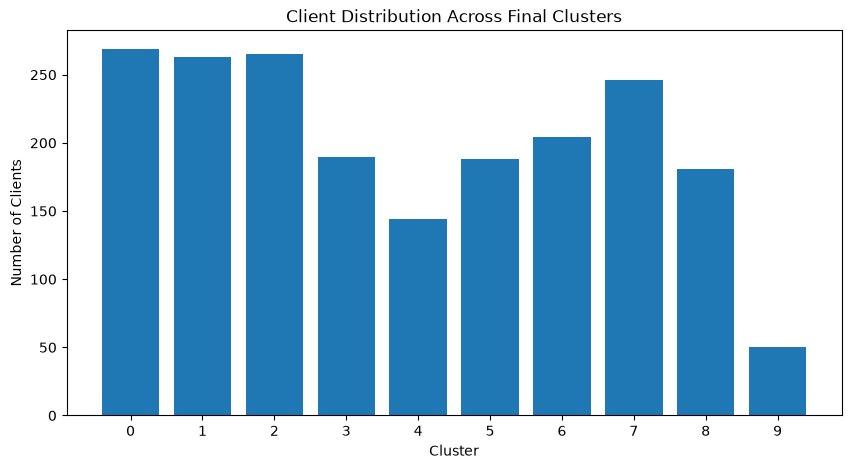

In [99]:
import matplotlib.pyplot as plt

cluster_counts = (
    final_clustered_df['cluster']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel('Cluster')
plt.ylabel('Number of Clients')
plt.title('Client Distribution Across Final Clusters')

plt.show()

### 26.1 Property Activity by Cluster

The average number of properties associated with each cluster is visualized to compare property ownership or activity across buyer segments.

This helps identify clusters with relatively higher levels of property activity.

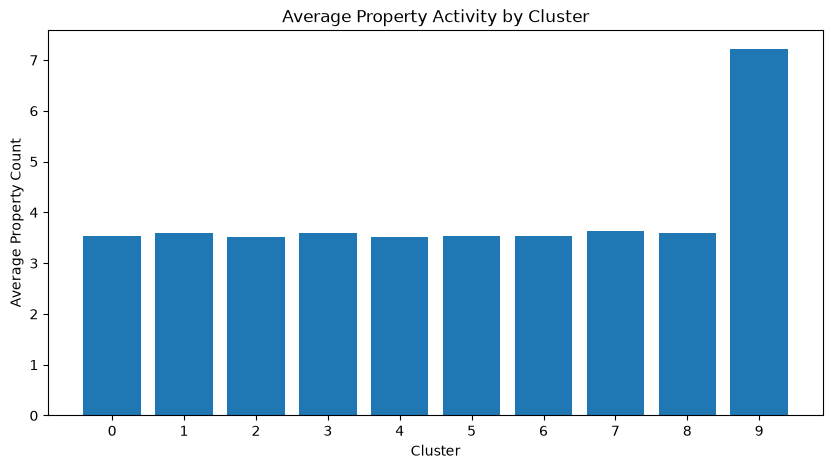

In [100]:
property_activity = (
    final_clustered_df.groupby('cluster')['property_count']
    .mean()
)

plt.figure(figsize=(10, 5))

plt.bar(
    property_activity.index.astype(str),
    property_activity.values
)

plt.xlabel('Cluster')
plt.ylabel('Average Property Count')
plt.title('Average Property Activity by Cluster')

plt.show()

### 26.2 Total Property Value by Cluster

The average total property value associated with each cluster is visualized to compare the overall property value represented by different buyer segments.

Total property value is treated as a proxy for investment scale because the dataset does not contain an income variable.

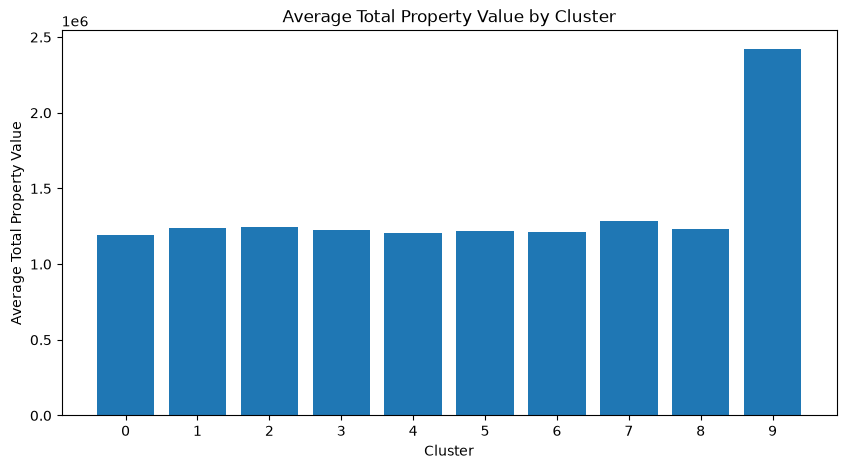

In [101]:
property_value = (
    final_clustered_df.groupby('cluster')['total_property_value']
    .mean()
)

plt.figure(figsize=(10, 5))

plt.bar(
    property_value.index.astype(str),
    property_value.values
)

plt.xlabel('Cluster')
plt.ylabel('Average Total Property Value')
plt.title('Average Total Property Value by Cluster')

plt.show()

### 26.3 Acquisition Purpose by Cluster

The distribution of acquisition purpose within each cluster is visualized to compare home-oriented and investment-oriented buyers.

Percentages are calculated within each cluster to allow meaningful comparison between segments of different sizes.

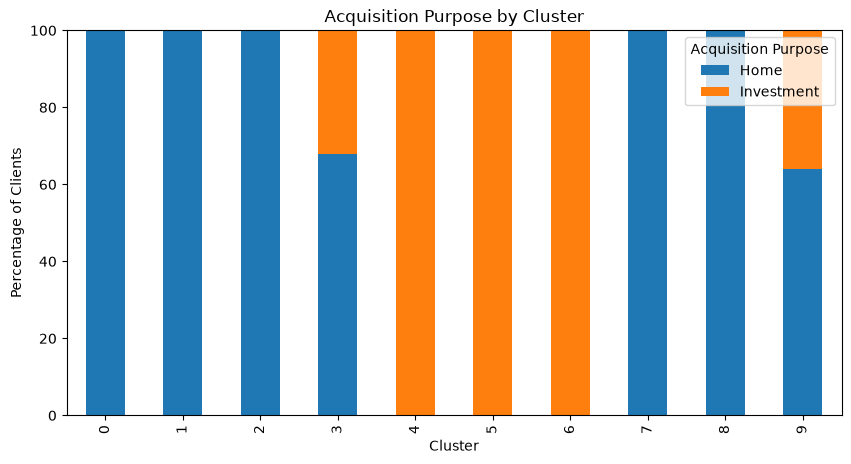

In [102]:
purpose_profile = pd.crosstab(
    final_clustered_df['cluster'],
    final_clustered_df['acquisition_purpose'],
    normalize='index'
) * 100

purpose_profile.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)

plt.xlabel('Cluster')
plt.ylabel('Percentage of Clients')
plt.title('Acquisition Purpose by Cluster')
plt.legend(title='Acquisition Purpose')

plt.show()


### 26.4 Loan Behavior by Cluster

The proportion of clients applying for loans is compared across the final clusters.

This helps identify differences in financing behavior between buyer segments.

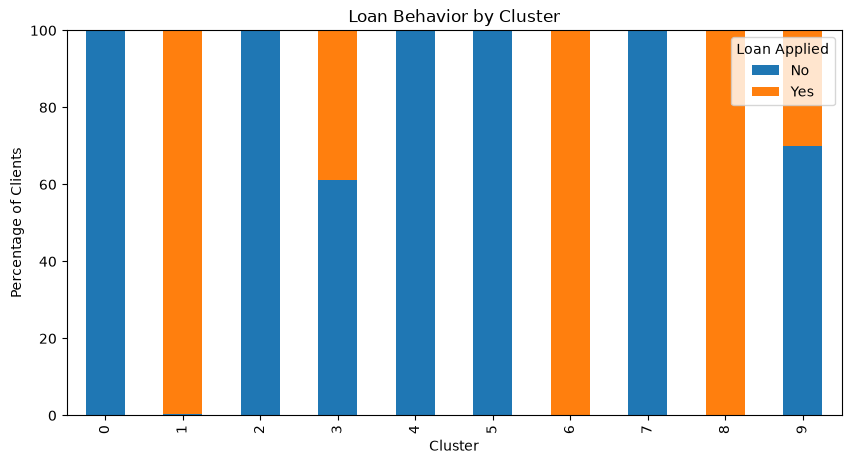

In [103]:
loan_profile = pd.crosstab(
    final_clustered_df['cluster'],
    final_clustered_df['loan_applied'],
    normalize='index'
) * 100

loan_profile.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 5)
)

plt.xlabel('Cluster')
plt.ylabel('Percentage of Clients')
plt.title('Loan Behavior by Cluster')
plt.legend(title='Loan Applied')

plt.show()

### 26.5 Geographic Distribution of Buyer Segments

The distribution of buyer segments across countries is examined to identify geographic differences in the composition of the clusters.

Country is used for interpretation and visualization rather than as a final clustering feature.

In [104]:
country_cluster = pd.crosstab(
    final_clustered_df['country'],
    final_clustered_df['cluster']
)

country_cluster

cluster,0,1,2,3,4,5,6,7,8,9
country,,,,,,,,,,
Australia,7,2,9,7,1,4,2,1,6,0
Belgium,7,1,6,3,4,6,5,8,2,1
Canada,14,7,8,7,7,10,14,9,8,1
Denmark,1,2,1,0,1,1,2,4,3,0
France,2,9,7,7,3,5,5,8,6,1
Germany,6,10,6,6,2,6,6,8,5,1
Mexico,5,5,1,5,4,6,4,4,5,1
Russia,2,1,10,1,2,2,3,8,7,0
UK,8,19,14,8,6,10,7,14,6,3


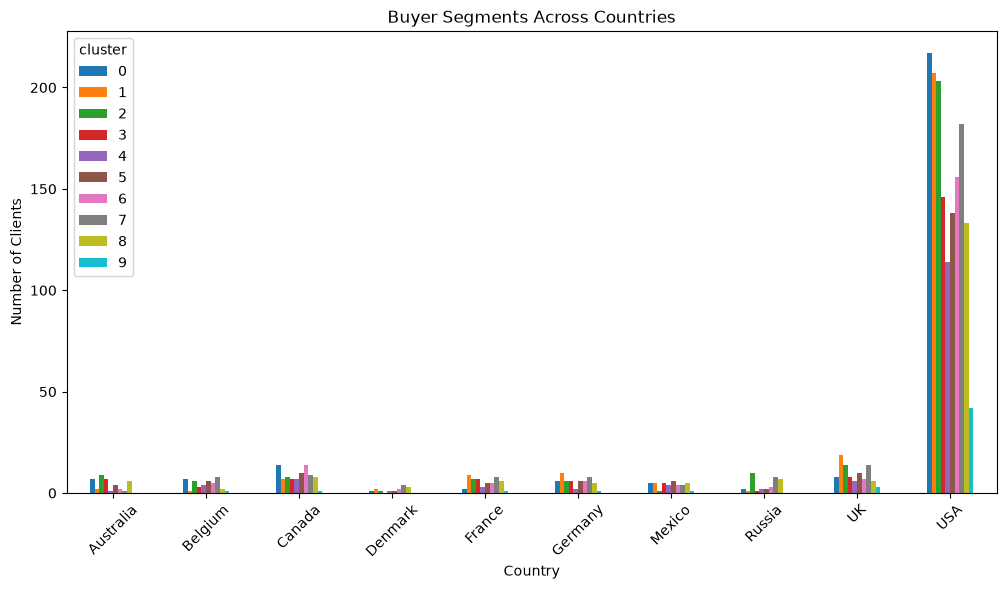

In [105]:
country_cluster.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.xlabel('Country')
plt.ylabel('Number of Clients')
plt.title('Buyer Segments Across Countries')
plt.xticks(rotation=45)

plt.show()

## 27. Business Insights from Buyer Segments

The final clusters are analyzed to identify meaningful differences in buyer behavior, financing patterns, property activity, and demographics.

These observations are used to develop data-driven insights that can support targeted marketing and real estate investment strategies.

### 27.1 Cluster Size Analysis

The number of clients assigned to each cluster is calculated to understand the relative size of the identified buyer segments.

This helps determine whether a segment represents a large portion of the client base or a smaller specialized group.

In [106]:
cluster_sizes = (
    final_clustered_df['cluster']
    .value_counts()
    .sort_index()
)

cluster_sizes

cluster
0    269
1    263
2    265
3    190
4    144
5    188
6    204
7    246
8    181
9     50
Name: count, dtype: int64

### 27.2 Property Activity Analysis

The average number of properties associated with each cluster is calculated to identify segments with relatively higher or lower property activity.

A higher property count indicates greater property activity within the dataset, but it does not by itself indicate client income or wealth.

In [109]:
property_activity_by_cluster = (
    final_clustered_df
    .groupby('cluster')['property_count']
    .mean()
    .sort_values(ascending=False)
)

property_activity_by_cluster

cluster
9    7.220000
7    3.638211
1    3.600760
8    3.591160
3    3.584211
5    3.537234
0    3.535316
6    3.529412
4    3.513889
2    3.505660
Name: property_count, dtype: float64

### 27.3 Property Value Analysis

The average total property value is calculated for each cluster to compare the property value associated with different buyer segments.

Because the client dataset does not contain an income variable, total property value is interpreted as a proxy for property investment scale rather than as a measure of client income.

In [108]:
property_value_by_cluster = (
    final_clustered_df
    .groupby('cluster')['total_property_value']
    .mean()
    .sort_values(ascending=False)
)

property_value_by_cluster

cluster
9    2.422650e+06
7    1.286403e+06
2    1.247266e+06
1    1.236174e+06
8    1.234618e+06
3    1.227456e+06
5    1.217511e+06
6    1.214032e+06
4    1.206564e+06
0    1.191605e+06
Name: total_property_value, dtype: float64

### 27.4 Investment-Oriented Buyer Analysis

The percentage of clients whose acquisition purpose is recorded as `Investment` is calculated for each cluster.

This helps identify clusters with a stronger investment-oriented profile.

In [110]:
investment_percentage = (
    final_clustered_df
    .groupby('cluster')['acquisition_purpose']
    .apply(lambda x: (x == 'Investment').mean() * 100)
    .round(2)
)

investment_percentage

cluster
0      0.00
1      0.00
2      0.00
3     32.11
4    100.00
5    100.00
6    100.00
7      0.00
8      0.00
9     36.00
Name: acquisition_purpose, dtype: float64

### 27.5 Business Insight Summary

The key cluster-level measures are combined into a consolidated business insight table.

The table summarizes segment size, property activity, property value, and investment orientation, providing a concise view of the characteristics that can support business interpretation.

In [111]:
business_insights = pd.DataFrame({
    'Clients': cluster_sizes,
    'Avg_Property_Count': (
        final_clustered_df
        .groupby('cluster')['property_count']
        .mean()
    ),
    'Avg_Total_Property_Value': (
        final_clustered_df
        .groupby('cluster')['total_property_value']
        .mean()
    ),
    'Investment_Percentage': investment_percentage
}).round(2)

business_insights

,Clients,Avg_Property_Count,Avg_Total_Property_Value,Investment_Percentage
cluster,,,,
0,269,3.54,1191604.77,0.00
1,263,3.60,1236173.91,0.00
2,265,3.51,1247266.16,0.00
3,190,3.58,1227456.12,32.11
4,144,3.51,1206563.61,100.00
5,188,3.54,1217510.57,100.00
6,204,3.53,1214032.44,100.00
7,246,3.64,1286403.23,0.00
8,181,3.59,1234618.28,0.00


## 28. Business Recommendations

The identified buyer segments provide insights that can support more targeted real estate marketing and customer engagement strategies.

Recommendations are based on the observed characteristics of each cluster, including acquisition purpose, financing behavior, referral channel, property activity, and property value.

### 28.1 Purpose-Based Targeting

The clusters show clear differences between home-oriented and investment-oriented buyers.

Clusters 4, 5, and 6 consist entirely of investment-oriented buyers, while clusters 0, 1, 2, 7, and 8 consist entirely of home-oriented buyers.

This distinction can support separate marketing approaches for personal-use buyers and investment-oriented buyers.

### 28.2 Financing-Based Targeting

Loan behavior varies substantially across the identified clusters.

Clusters 1 and 6 have almost all clients applying for loans, while clusters 0, 2, 4, and 5 predominantly consist of clients who did not apply for loans.

This information can support differentiated communication around financing options and property purchasing.

### 28.3 Referral Channel Strategy

Referral channels also distinguish several buyer segments.

Some clusters are strongly associated with Agency referrals, while others are predominantly associated with Website referrals. Cluster 3 is primarily associated with Client referrals.

This suggests that marketing and customer acquisition strategies can be evaluated separately across different referral channels.

### 28.4 High Property-Activity Segment

Cluster 9 represents a relatively small segment of 50 clients but has substantially higher property activity than the other clusters.

The segment averages 7.22 properties per client and approximately $2.42 million in total property value per client.

This makes Cluster 9 particularly relevant for analyzing customers with higher levels of property activity and larger property-value exposure.

The results should not be interpreted as evidence of higher income because income is not available in the dataset.

### 28.5 Segment Summary for Business Use

The main characteristics of the identified clusters are summarized below to provide a concise reference for business interpretation and dashboard development.

In [112]:
segment_summary = pd.DataFrame({
    'Cluster': range(10),
    'Clients': cluster_sizes.values,
    'Avg Property Count': (
        final_clustered_df
        .groupby('cluster')['property_count']
        .mean()
        .values
    ),
    'Avg Total Property Value': (
        final_clustered_df
        .groupby('cluster')['total_property_value']
        .mean()
        .values
    ),
    'Investment %': investment_percentage.values
}).round(2)

segment_summary

,Cluster,Clients,Avg Property Count,Avg Total Property Value,Investment %
0,0,269,3.54,1191604.77,0.00
1,1,263,3.60,1236173.91,0.00
2,2,265,3.51,1247266.16,0.00
3,3,190,3.58,1227456.12,32.11
4,4,144,3.51,1206563.61,100.00
5,5,188,3.54,1217510.57,100.00
6,6,204,3.53,1214032.44,100.00
7,7,246,3.64,1286403.23,0.00
8,8,181,3.59,1234618.28,0.00
9,9,50,7.22,2422649.51,36.00
